# Risk AI Assistant — Scoring Crédit, Détection d'Anomalies & Explicabilité Métier

## 1. Contexte métier

Ce POC illustre une pipeline simple d'aide à la décision pour une équipe Risques bancaire.
Il couvre la qualité des données, le scoring du risque de crédit, la détection de dossiers atypiques, l'interprétation du modèle et une synthèse métier exploitable.
Le modèle produit un signal de priorisation, pas une décision automatique.
En pratique, ce type d'approche aide à orienter les dossiers vers une revue manuelle lorsque les signaux de risque sont élevés ou incohérents.
La lisibilité des facteurs de risque est aussi importante que la performance statistique, car une décision de crédit doit pouvoir être discutée, contrôlée et documentée.

## 2. Imports & configuration

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'simulated_credit_risk_dataset.csv'
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

## 3. Génération ou chargement du dataset

Le dataset est chargé depuis `data/simulated_credit_risk_dataset.csv`. Si le fichier est absent, il est régénéré avec une logique simple : l'endettement, les incidents récents et un défaut passé augmentent le risque ; le revenu, l'épargne et un historique stable le réduisent.

In [3]:
def generate_simulated_credit_risk_dataset(path, n_rows=1500, random_state=42):
    rng = np.random.default_rng(random_state)

    age = np.clip(rng.normal(42, 11, n_rows).round().astype(int), 21, 74)
    annual_income = np.clip(rng.lognormal(np.log(48000), 0.42, n_rows), 16000, 180000).round(0)
    employment_years = np.minimum(
        np.clip(rng.gamma(3.0, 2.5, n_rows), 0, 40),
        np.maximum(age - 18, 0),
    ).round(1)
    credit_history_years = np.minimum(
        np.clip(rng.normal(age - 25, 5.5, n_rows), 0.5, 45),
        np.maximum(age - 18, 0),
    ).round(1)
    savings_amount = np.clip(
        annual_income * rng.beta(1.5, 7.0, n_rows) + rng.normal(0, 1200, n_rows),
        0,
        90000,
    ).round(0)

    sectors = np.array(['Retail', 'Services', 'Manufacturing', 'Technology', 'Healthcare', 'Construction', 'Public sector'])
    sector = rng.choice(sectors, size=n_rows, p=[0.20, 0.24, 0.14, 0.13, 0.12, 0.10, 0.07])
    regions = np.array(['Ile-de-France', 'Auvergne-Rhone-Alpes', 'Nouvelle-Aquitaine', 'Occitanie', 'Hauts-de-France', 'Grand Est'])
    region = rng.choice(regions, size=n_rows, p=[0.30, 0.16, 0.14, 0.14, 0.14, 0.12])

    esg_shift = {
        'Retail': -2,
        'Services': 1,
        'Manufacturing': -5,
        'Technology': 6,
        'Healthcare': 4,
        'Construction': -7,
        'Public sector': 8,
    }
    esg_score = np.clip(np.array([58 + esg_shift[s] for s in sector]) + rng.normal(0, 14, n_rows), 5, 98).round(0)

    low_income_pressure = np.clip((42000 - annual_income) / 90000, 0, 0.25)
    debt_to_income = np.clip(
        rng.beta(2.1, 5.2, n_rows) * 1.15 + low_income_pressure - savings_amount / annual_income * 0.05,
        0.02,
        1.25,
    )
    previous_default = rng.binomial(1, np.clip(0.035 + 0.18 * debt_to_income + 0.08 * low_income_pressure, 0.02, 0.28))
    missed_payments_12m = np.clip(
        rng.poisson(np.clip(0.25 + 1.8 * debt_to_income + 1.2 * previous_default - savings_amount / 70000, 0.05, 5.0)),
        0,
        9,
    )
    loan_amount = np.clip(
        annual_income * (rng.uniform(0.18, 0.95, n_rows) + 0.22 * debt_to_income) + rng.normal(0, 3500, n_rows),
        3000,
        120000,
    ).round(0)

    sector_risk = {'Retail': 0.10, 'Services': 0.00, 'Manufacturing': 0.08, 'Technology': -0.08, 'Healthcare': -0.05, 'Construction': 0.18, 'Public sector': -0.12}
    region_risk = {'Ile-de-France': -0.04, 'Auvergne-Rhone-Alpes': -0.02, 'Nouvelle-Aquitaine': 0.00, 'Occitanie': 0.02, 'Hauts-de-France': 0.05, 'Grand Est': 0.03}
    z = (
        -2.05
        + 2.65 * debt_to_income
        + 0.36 * missed_payments_12m
        + 1.45 * previous_default
        + 0.000010 * loan_amount
        - 0.000010 * annual_income
        - 0.000018 * savings_amount
        - 0.035 * employment_years
        - 0.025 * credit_history_years
        - 0.006 * esg_score
        + np.array([sector_risk[s] for s in sector])
        + np.array([region_risk[r] for r in region])
        + rng.normal(0, 0.55, n_rows)
    )
    risk_label = rng.binomial(1, 1 / (1 + np.exp(-z)))

    df_generated = pd.DataFrame({
        'customer_id': [f'CUST{i:06d}' for i in range(1, n_rows + 1)],
        'age': age,
        'annual_income': annual_income,
        'debt_to_income': np.round(debt_to_income, 3),
        'loan_amount': loan_amount,
        'employment_years': employment_years,
        'previous_default': previous_default,
        'missed_payments_12m': missed_payments_12m,
        'credit_history_years': credit_history_years,
        'savings_amount': savings_amount,
        'esg_score': esg_score,
        'sector': sector,
        'region': region,
        'risk_label': risk_label,
    })

    high_loan_idx = rng.choice(df_generated.index, size=8, replace=False)
    df_generated.loc[high_loan_idx, 'annual_income'] = rng.integers(9000, 15000, size=len(high_loan_idx))
    df_generated.loc[high_loan_idx, 'loan_amount'] = rng.integers(85000, 140000, size=len(high_loan_idx))
    df_generated.loc[high_loan_idx, 'debt_to_income'] = rng.uniform(1.45, 2.35, size=len(high_loan_idx)).round(3)
    df_generated.loc[high_loan_idx, 'risk_label'] = rng.binomial(1, 0.82, size=len(high_loan_idx))

    remaining = df_generated.index.difference(high_loan_idx)
    high_dti_idx = rng.choice(remaining, size=8, replace=False)
    df_generated.loc[high_dti_idx, 'debt_to_income'] = rng.uniform(1.55, 2.60, size=len(high_dti_idx)).round(3)
    df_generated.loc[high_dti_idx, 'missed_payments_12m'] = rng.integers(4, 9, size=len(high_dti_idx))
    df_generated.loc[high_dti_idx, 'risk_label'] = rng.binomial(1, 0.78, size=len(high_dti_idx))

    remaining = df_generated.index.difference(np.concatenate([high_loan_idx, high_dti_idx]))
    history_idx = rng.choice(remaining, size=8, replace=False)
    df_generated.loc[history_idx, 'credit_history_years'] = (df_generated.loc[history_idx, 'age'] - 12 + rng.uniform(0, 8, size=len(history_idx))).round(1)
    df_generated.loc[history_idx, 'employment_years'] = (df_generated.loc[history_idx, 'age'] - 14 + rng.uniform(0, 5, size=len(history_idx))).round(1)
    df_generated.loc[history_idx, 'risk_label'] = rng.binomial(1, 0.45, size=len(history_idx))

    for column, count in {'annual_income': 10, 'employment_years': 8, 'savings_amount': 8, 'esg_score': 6}.items():
        df_generated.loc[rng.choice(df_generated.index, size=count, replace=False), column] = np.nan

    duplicate_idx = rng.choice(df_generated.index, size=6, replace=False)
    df_generated = pd.concat([df_generated, df_generated.loc[duplicate_idx]], ignore_index=True)

    path.parent.mkdir(parents=True, exist_ok=True)
    df_generated.to_csv(path, index=False, encoding='utf-8')
    return df_generated


if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Dataset chargé depuis {DATA_PATH}')
else:
    df = generate_simulated_credit_risk_dataset(DATA_PATH, random_state=RANDOM_STATE)
    print(f'Dataset généré dans {DATA_PATH}')

Dataset chargé depuis c:\00_VSC_Projects\Savoir_Coder\entretiens_projets\credit_scoring_AI\risk-ai-assistant-credit-scoring\data\simulated_credit_risk_dataset.csv


## 4. Vue d'ensemble des données

In [4]:
print('Shape:', df.shape)
display(df.head())

display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)

Shape: (1506, 14)


,customer_id,age,annual_income,debt_to_income,loan_amount,employment_years,previous_default,missed_payments_12m,credit_history_years,savings_amount,esg_score,sector,region,risk_label
0,CUST000001,45,"37,840.000",0.452,"11,518.000",13.200,0,0,17.000,"10,355.000",54.000,Public sector,Occitanie,0
1,CUST000002,31,"36,924.000",0.107,"28,971.000",13.000,0,2,0.500,"3,546.000",45.000,Retail,Ile-de-France,0
2,CUST000003,50,"83,744.000",0.702,"48,525.000",5.600,0,1,20.900,"16,693.000",46.000,Services,Auvergne-Rhone-Alpes,0
3,CUST000004,52,"55,143.000",0.320,"19,207.000",1.400,0,2,34.000,"5,008.000",56.000,Construction,Occitanie,1
4,CUST000005,21,"43,916.000",0.135,"21,964.000",3.000,0,1,0.500,"2,172.000",56.000,Services,Ile-de-France,0


,dtype
customer_id,str
age,int64
annual_income,float64
debt_to_income,float64
loan_amount,float64
employment_years,float64
previous_default,int64
missed_payments_12m,int64
credit_history_years,float64
savings_amount,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1506,1500,CUST000213,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"1,506.000",NaN,NaN,NaN,41.916,10.688,21.000,34.250,42.000,49.000,74.000
annual_income,"1,496.000",NaN,NaN,NaN,"51,769.303","23,211.707","9,456.000","35,784.000","47,818.000","63,045.750","173,505.000"
debt_to_income,"1,506.000",NaN,NaN,NaN,0.388,0.252,0.020,0.232,0.352,0.506,2.320
loan_amount,"1,506.000",NaN,NaN,NaN,"33,678.799","20,056.703","3,000.000","19,888.000","29,143.000","42,163.500","139,011.000"
employment_years,"1,498.000",NaN,NaN,NaN,7.201,4.174,0.300,4.100,6.500,9.300,44.800
previous_default,"1,506.000",NaN,NaN,NaN,0.097,0.296,0.000,0.000,0.000,0.000,1.000
missed_payments_12m,"1,506.000",NaN,NaN,NaN,0.946,1.194,0.000,0.000,1.000,1.000,9.000
credit_history_years,"1,506.000",NaN,NaN,NaN,17.188,11.070,0.500,8.400,17.000,25.000,46.200
savings_amount,"1,498.000",NaN,NaN,NaN,"9,409.004","8,662.961",0.000,"3,423.750","7,145.000","12,524.000","59,837.000"


,count,share
risk_label,,
0,1253,0.832
1,253,0.168


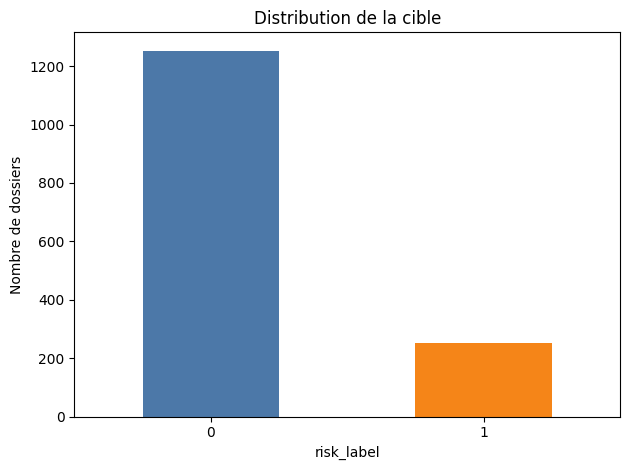

In [5]:
target_distribution = df['risk_label'].value_counts().sort_index().to_frame('count')
target_distribution['share'] = target_distribution['count'] / len(df)
display(target_distribution)

ax = target_distribution['count'].plot(kind='bar', color=['#4C78A8', '#F58518'], rot=0)
ax.set_title('Distribution de la cible')
ax.set_xlabel('risk_label')
ax.set_ylabel('Nombre de dossiers')
plt.tight_layout()
plt.show()

## 5. Contrôles de qualité des données

La qualité des données est critique en risque bancaire : un modèle peut être techniquement fiable sur un jeu d'apprentissage, mais produire une mauvaise décision si les données sont incomplètes, incohérentes ou mal contrôlées.

In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0].to_frame('missing_count'))

duplicate_rows = int(df.duplicated().sum())
duplicate_customer_ids = int(df['customer_id'].duplicated().sum())
display(pd.DataFrame({
    'check': ['exact_duplicate_rows', 'duplicate_customer_ids'],
    'count': [duplicate_rows, duplicate_customer_ids],
}))

quality_checks = pd.DataFrame({
    'check': [
        'credit_history_above_possible_age',
        'employment_years_above_possible_age',
        'debt_to_income_above_1',
        'debt_to_income_above_1_5',
        'annual_income_below_12000',
        'loan_amount_above_100000',
        'low_income_high_loan',
    ],
    'count': [
        int((df['credit_history_years'] > (df['age'] - 18)).sum()),
        int((df['employment_years'] > (df['age'] - 18)).sum()),
        int((df['debt_to_income'] > 1.0).sum()),
        int((df['debt_to_income'] > 1.5).sum()),
        int((df['annual_income'] < 12000).sum()),
        int((df['loan_amount'] > 100000).sum()),
        int(((df['annual_income'] < 15000) & (df['loan_amount'] > 80000)).sum()),
    ],
})
display(quality_checks)

numeric_columns = df.select_dtypes(include=np.number).columns
extreme_snapshot = df[numeric_columns].quantile([0.01, 0.50, 0.99]).T
display(extreme_snapshot)

,missing_count
annual_income,10
employment_years,8
savings_amount,8
esg_score,6


,check,count
0,exact_duplicate_rows,6
1,duplicate_customer_ids,6


,check,count
0,credit_history_above_possible_age,8
1,employment_years_above_possible_age,8
2,debt_to_income_above_1,19
3,debt_to_income_above_1_5,16
4,annual_income_below_12000,4
5,loan_amount_above_100000,22
6,low_income_high_loan,8


,0.010,0.500,0.990
age,21.000,42.000,67.000
annual_income,"16,088.350","47,818.000","130,816.000"
debt_to_income,0.033,0.352,1.500
loan_amount,"6,097.250","29,143.000","105,354.200"
employment_years,1.297,6.500,19.100
previous_default,0.000,0.000,1.000
missed_payments_12m,0.000,1.000,5.000
credit_history_years,0.500,17.000,42.800
savings_amount,0.000,"7,145.000","41,972.250"
esg_score,25.000,59.000,93.010


## 6. Rappels mathématiques

La régression logistique estime une probabilité à l'aide d'une fonction sigmoïde :

$$
p(y=1|x)=\frac{1}{1+e^{-z}}
$$

avec un score linéaire :

$$
z = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

Les coefficients indiquent comment chaque variable contribue aux log-odds du risque, après préparation des variables.

La binary cross-entropy pénalise les mauvaises estimations de probabilité :

$$
\mathcal{L}(y,\hat{p})=-\left[y\log(\hat{p})+(1-y)\log(1-\hat{p})\right]
$$

La precision mesure la part des alertes qui sont vraiment risquées :

$$
Precision=\frac{TP}{TP+FP}
$$

Le recall mesure la part des dossiers risqués détectés :

$$
Recall=\frac{TP}{TP+FN}
$$

Le F1-score équilibre precision et recall :

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

## 7. Préparation des variables

Les doublons exacts sont retirés avant l'entraînement. Les valeurs manquantes sont imputées dans une pipeline `sklearn`, ce qui évite toute fuite entre train et test.

In [7]:
model_df = df.drop_duplicates().copy()

target = 'risk_label'
id_column = 'customer_id'
categorical_features = ['sector', 'region']
numeric_features = [
    'age',
    'annual_income',
    'debt_to_income',
    'loan_amount',
    'employment_years',
    'previous_default',
    'missed_payments_12m',
    'credit_history_years',
    'savings_amount',
    'esg_score',
]

X = model_df[numeric_features + categorical_features]
y = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)


def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])


print('Dimensions train :', X_train.shape)
print('Dimensions test :', X_test.shape)
print('Taux de risque train :', round(y_train.mean(), 3))
print('Taux de risque test :', round(y_test.mean(), 3))

Dimensions train : (1125, 12)
Dimensions test : (375, 12)
Taux de risque train : 0.168
Taux de risque test : 0.168


## 8. Modèle de référence

La régression logistique est utilisée comme modèle principal : elle est simple, interprétable, adaptée à un premier POC et facile à expliquer à des interlocuteurs Risques comme à des data scientists.

In [8]:
def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
    }, y_pred, y_score


log_reg_model = Pipeline(steps=[
    ('preprocessor', build_preprocessor()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
])

log_reg_model.fit(X_train, y_train)
log_reg_metrics, log_reg_pred, log_reg_score = evaluate_classifier(log_reg_model, X_test, y_test, 'Régression logistique')

display(pd.DataFrame([log_reg_metrics]).round(3))
display(pd.DataFrame(
    confusion_matrix(y_test, log_reg_pred),
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1'],
))

,model,accuracy,precision,recall,f1_score,roc_auc
0,Régression logistique,0.728,0.341,0.667,0.452,0.756


,Predicted 0,Predicted 1
Actual 0,231,81
Actual 1,21,42


Interprétation métier : un recall élevé signifie que le modèle détecte une part plus importante des dossiers risqués. Une precision élevée signifie que les alertes contiennent moins de faux positifs. En risque de crédit, le bon compromis dépend du coût métier d'un faux négatif, c'est-à-dire accepter un dossier risqué, et d'un faux positif, c'est-à-dire déclencher une revue inutile.

## 9. Modèle de comparaison

Une Random Forest est ajoutée comme comparaison rapide. Elle peut capter des effets non linéaires, mais elle est moins directe à expliquer qu'une régression logistique.

In [9]:
rf_model = Pipeline(steps=[
    ('preprocessor', build_preprocessor()),
    ('model', RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

rf_model.fit(X_train, y_train)
rf_metrics, rf_pred, rf_score = evaluate_classifier(rf_model, X_test, y_test, 'Forêt aléatoire')

comparison = pd.DataFrame([log_reg_metrics, rf_metrics]).set_index('model')
display(comparison.round(3))

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Régression logistique,0.728,0.341,0.667,0.452,0.756
Forêt aléatoire,0.776,0.385,0.556,0.455,0.762


## 10. Importance des variables

L'interprétabilité permet de comprendre les facteurs de risque et d'éviter un modèle boîte noire non contrôlé. Les coefficients de la régression logistique sont lus après standardisation des variables numériques et encodage des variables catégorielles.

In [10]:
feature_names = log_reg_model.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = pd.Series(feature_names).str.replace('^num__', '', regex=True).str.replace('^cat__', '', regex=True)
coefficients = log_reg_model.named_steps['model'].coef_[0]

coefficient_table = pd.DataFrame({
    'feature': clean_feature_names,
    'coefficient': coefficients,
}).sort_values('coefficient', ascending=False)

print('Variables qui augmentent le risque estimé')
display(coefficient_table.head(10).round(3))

print('Variables qui réduisent le risque estimé')
display(coefficient_table.tail(10).sort_values('coefficient').round(3))

Variables qui augmentent le risque estimé


,feature,coefficient
2,debt_to_income,0.532
5,previous_default,0.458
22,region_Occitanie,0.289
13,sector_Public sector,0.254
3,loan_amount,0.240
10,sector_Construction,0.240
6,missed_payments_12m,0.204
19,region_Hauts-de-France,0.106
0,age,0.023
17,region_Auvergne-Rhone-Alpes,-0.002


Variables qui réduisent le risque estimé


,feature,coefficient
21,region_Nouvelle-Aquitaine,-0.364
8,savings_amount,-0.354
11,sector_Healthcare,-0.287
7,credit_history_years,-0.233
9,esg_score,-0.169
1,annual_income,-0.164
15,sector_Services,-0.129
18,region_Grand Est,-0.117
4,employment_years,-0.113
14,sector_Retail,-0.101


In [11]:
rf_feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
rf_clean_feature_names = pd.Series(rf_feature_names).str.replace('^num__', '', regex=True).str.replace('^cat__', '', regex=True)
rf_importance_table = pd.DataFrame({
    'feature': rf_clean_feature_names,
    'importance': rf_model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False)

print('Importance des variables - Random Forest')
display(rf_importance_table.head(10).round(3))

Importance des variables - Random Forest


,feature,importance
2,debt_to_income,0.222
5,previous_default,0.109
8,savings_amount,0.102
1,annual_income,0.089
6,missed_payments_12m,0.078
9,esg_score,0.070
3,loan_amount,0.069
4,employment_years,0.069
7,credit_history_years,0.063
0,age,0.060


## 11. Détection d'anomalies

Isolation Forest est utilisé pour identifier les dossiers atypiques. L'objectif n'est pas de prédire directement le défaut, mais de repérer des observations dont le profil est inhabituel.

Un dossier peut être atypique sans être automatiquement mauvais. Il doit plutôt être orienté vers une revue manuelle.

In [12]:
anomaly_features = numeric_features
anomaly_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', IsolationForest(contamination=0.04, random_state=RANDOM_STATE)),
])

anomaly_flags = anomaly_pipeline.fit_predict(model_df[anomaly_features])
model_df['is_anomaly'] = anomaly_flags == -1

print('Anomalies détectées :', int(model_df['is_anomaly'].sum()))
anomaly_examples = model_df.loc[model_df['is_anomaly'], [
    'customer_id',
    'annual_income',
    'debt_to_income',
    'loan_amount',
    'employment_years',
    'credit_history_years',
    'previous_default',
    'missed_payments_12m',
    'risk_label',
]].sort_values(['debt_to_income', 'loan_amount'], ascending=False)

display(anomaly_examples.head(10))

Anomalies détectées : 60


,customer_id,annual_income,debt_to_income,loan_amount,employment_years,credit_history_years,previous_default,missed_payments_12m,risk_label
1210,CUST001211,"14,646.000",2.320,"86,700.000",9.400,22.000,0,4,0
332,CUST000333,"30,022.000",2.274,"11,887.000",16.000,12.100,0,4,1
979,CUST000980,"42,673.000",2.190,"33,315.000",10.000,25.400,0,8,1
1015,CUST001016,"37,520.000",2.126,"35,904.000",10.400,6.200,0,8,0
74,CUST000075,"26,067.000",2.112,"20,284.000",8.300,12.400,0,7,1
524,CUST000525,"27,416.000",2.107,"26,635.000",3.500,39.000,0,6,1
242,CUST000243,"9,456.000",2.061,"86,694.000",5.000,5.000,1,2,1
1390,CUST001391,"12,170.000",2.026,"132,317.000",3.800,17.000,0,0,1
894,CUST000895,"13,977.000",1.885,"134,549.000",7.500,12.900,0,0,1
1316,CUST001317,"12,342.000",1.875,"97,934.000",7.600,10.300,0,0,1


## 12. Génération d'une synthèse métier

La synthèse ci-dessous est produite par des règles contrôlées. Elle n'appelle pas de vrai LLM. Une extension possible serait de brancher un LLM interne ou un RAG contrôlé pour produire des notes plus riches, avec validation humaine et traçabilité.

In [13]:
from risk_summary import generate_risk_summary


def business_factor_label(feature_name):
    if feature_name.startswith('debt_to_income'):
        return "un taux d'endettement élevé"
    if feature_name.startswith('missed_payments_12m'):
        return 'des incidents de paiement récents'
    if feature_name.startswith('previous_default'):
        return 'un historique de défaut'
    if feature_name.startswith('annual_income'):
        return 'un revenu disponible limité'
    if feature_name.startswith('savings_amount'):
        return "un niveau d'épargne insuffisant"
    if feature_name.startswith('loan_amount'):
        return 'un montant de prêt important'
    if feature_name.startswith('credit_history_years'):
        return 'un historique de crédit limité ou atypique'
    if feature_name.startswith('employment_years'):
        return 'une stabilité professionnelle limitée'
    if feature_name.startswith('sector_'):
        return "un secteur d'activité plus exposé"
    if feature_name.startswith('region_'):
        return 'un effet régional observé dans les données'
    return feature_name.replace('_', ' ')


def top_positive_factors_for_client(model, client_features, max_factors=3):
    transformed = model.named_steps['preprocessor'].transform(client_features)
    if hasattr(transformed, 'toarray'):
        transformed = transformed.toarray()
    transformed = np.asarray(transformed).ravel()

    feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    clean_names = pd.Series(feature_names).str.replace('^num__', '', regex=True).str.replace('^cat__', '', regex=True)
    coefficients = model.named_steps['model'].coef_[0]
    contributions = pd.DataFrame({
        'feature': clean_names,
        'contribution': transformed * coefficients,
    }).sort_values('contribution', ascending=False)

    labels = []
    for feature in contributions.loc[contributions['contribution'] > 0, 'feature']:
        label = business_factor_label(feature)
        if label not in labels:
            labels.append(label)
        if len(labels) == max_factors:
            break
    return labels, contributions

## 13. Cas d'usage métier final

Cette section résume le cas d'usage de bout en bout : sélection d'un client, probabilité de risque, indicateur d'anomalie, principaux facteurs et synthèse métier.

In [14]:
test_results = X_test.copy()
test_results['risk_label'] = y_test
test_results['risk_probability'] = log_reg_score

selected_index = test_results.sort_values('risk_probability', ascending=False).index[0]
selected_client = X.loc[[selected_index]]
selected_customer_info = model_df.loc[selected_index].to_dict()

selected_probability = log_reg_model.predict_proba(selected_client)[0, 1]
selected_is_anomaly = bool(model_df.loc[selected_index, 'is_anomaly'])
top_factors, client_contributions = top_positive_factors_for_client(log_reg_model, selected_client)

summary = generate_risk_summary(
    selected_customer_info,
    selected_probability,
    top_factors,
    selected_is_anomaly,
)

display(model_df.loc[[selected_index], [
    'customer_id',
    'age',
    'annual_income',
    'debt_to_income',
    'loan_amount',
    'employment_years',
    'previous_default',
    'missed_payments_12m',
    'credit_history_years',
    'savings_amount',
    'esg_score',
    'sector',
    'region',
    'risk_label',
    'is_anomaly',
]])

print(f'Probabilité de risque estimée : {selected_probability:.1%}')
print('Indicateur d’anomalie :', 'Oui' if selected_is_anomaly else 'Non')
print('Principaux facteurs :', ', '.join(top_factors))
print('\nSynthèse métier :')
print(summary)

,customer_id,age,annual_income,debt_to_income,loan_amount,employment_years,previous_default,missed_payments_12m,credit_history_years,savings_amount,esg_score,sector,region,risk_label,is_anomaly
242,CUST000243,23,"9,456.000",2.061,"86,694.000",5.000,1,2,5.000,"7,696.000",56.000,Services,Grand Est,1,True


Probabilité de risque estimée : 99.8%
Indicateur d’anomalie : Oui
Principaux facteurs : un taux d'endettement élevé, un historique de défaut, un montant de prêt important

Synthèse métier :
Pour le dossier CUST000243, le risque estimé est élevé avec une probabilité de 99.8%. Les principaux facteurs sont un taux d'endettement élevé, un historique de défaut, un montant de prêt important. Le dossier est aussi détecté comme atypique par le module d'anomalie. Une revue manuelle prioritaire est recommandée.


## 14. Limites & gouvernance

* Les données sont simulées et ne représentent pas un portefeuille réel.
* Le modèle n'a pas de validation réglementaire.
* Des biais peuvent exister dans les données, les variables ou les seuils métier.
* Un monitoring est nécessaire pour suivre la performance et le drift des données.
* L'explicabilité doit être conservée pour permettre revue, audit et contestabilité.
* Un humain doit rester dans la boucle.
* Aucun refus ou accord de crédit ne doit être automatisé sans contrôle.

## 15. Conclusion

Ce POC montre une chaîne simple allant de la donnée brute à une restitution métier exploitable : data quality, scoring, détection d'anomalies, interprétabilité et synthèse. La valeur vient autant de la lisibilité du dispositif que de ses métriques.